<a href="https://colab.research.google.com/github/goitstudent123/numerical_programming_python/blob/main/%D0%94%D0%9714_%D0%93%D0%90%D0%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Load data
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

data = load_breast_cancer()
X = data.data
y = data.target  # 0 = malignant, 1 = benign
feature_names = data.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Split + scale for modeling steps
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

X_std = scaler.fit_transform(X)  # for clustering and PCA on full set
print(df.shape, np.bincount(y))


(569, 31) [212 357]


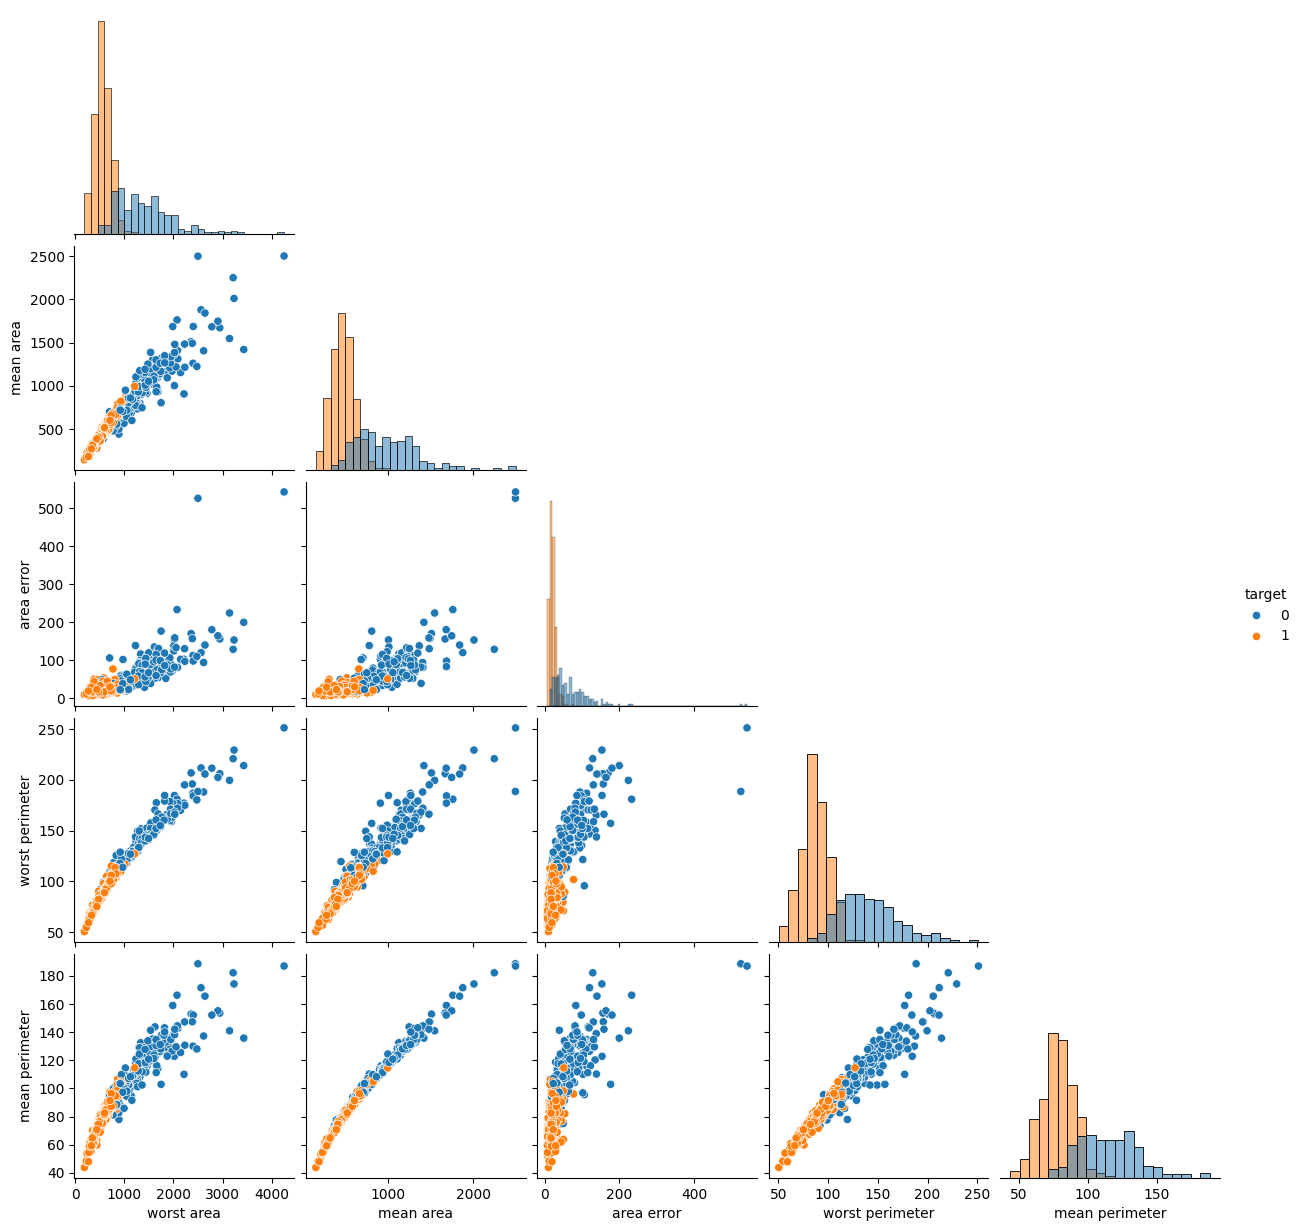

In [2]:
# Step 2: Pairwise scatter with a small subset (high variance features)
!pip -q install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

variances = df[feature_names].var().sort_values(ascending=False)
top_features = list(variances.index[:5])

sns.pairplot(df[top_features + ['target']], hue='target', diag_kind='hist', corner=True)
plt.show()


In [3]:
# Step 3: Clustering and comparison
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, accuracy_score
from scipy.optimize import linear_sum_assignment

def cluster_accuracy(true_labels, cluster_labels):
    # Map clusters to classes via Hungarian matching on confusion counts
    cm = pd.crosstab(true_labels, cluster_labels)
    cost = cm.max().sum() - cm.values  # maximize matches
    r, c = linear_sum_assignment(cost)
    acc = cm.values[r, c].sum() / cm.values.sum()
    mapping = dict(zip(c, r))
    mapped = np.vectorize(mapping.get)(cluster_labels)
    return acc, mapped

results_clust = {}

# KMeans
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init='auto')
km_labels = kmeans.fit_predict(X_std)
km_acc, km_mapped = cluster_accuracy(y, km_labels)
km_ari = adjusted_rand_score(y, km_labels)
results_clust['kmeans'] = {'acc_map': km_acc, 'ari': km_ari}

# Spectral
spec = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', n_neighbors=10,
                          random_state=RANDOM_STATE, assign_labels='kmeans')
sp_labels = spec.fit_predict(X_std)
sp_acc, sp_mapped = cluster_accuracy(y, sp_labels)
sp_ari = adjusted_rand_score(y, sp_labels)
results_clust['spectral'] = {'acc_map': sp_acc, 'ari': sp_ari}

# GMM
gmm = GaussianMixture(n_components=2, random_state=RANDOM_STATE)
gmm_labels = gmm.fit_predict(X_std)
gmm_acc, gmm_mapped = cluster_accuracy(y, gmm_labels)
gmm_ari = adjusted_rand_score(y, gmm_labels)
results_clust['gmm'] = {'acc_map': gmm_acc, 'ari': gmm_ari}

print(pd.DataFrame(results_clust).T)


           acc_map       ari
kmeans    0.912127  0.676505
spectral  0.936731  0.760801
gmm       0.940246  0.774016


In [4]:
# Step 4: PCA reduction
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_std)
print("Explained variance ratio:", pca.explained_variance_ratio_, "Sum:", pca.explained_variance_ratio_.sum())


Explained variance ratio: [0.44272026 0.18971182] Sum: 0.6324320765155944


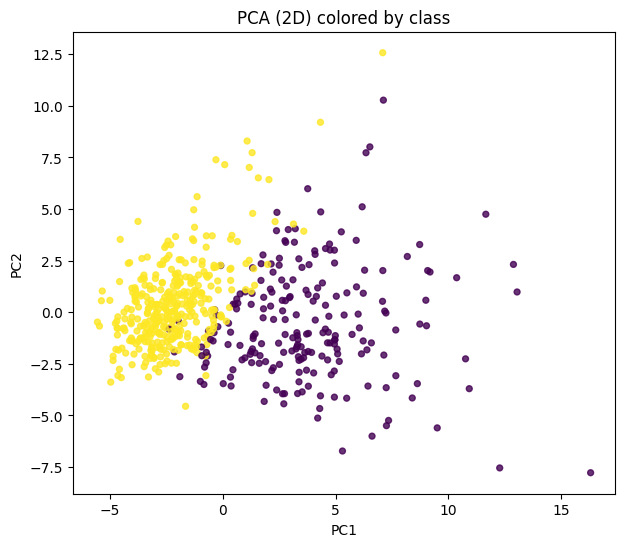

In [5]:
# Step 5: Visualize PCA scatters
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, s=18, alpha=0.8)
plt.title("PCA (2D) colored by class")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [6]:
# Step 6: LogisticRegression from sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_std, y_train)
y_pred_lr = logreg.predict(X_test_std)

cm_lr = confusion_matrix(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
acc_lr = accuracy_score(y_test, y_pred_lr)

results_cls = {}
results_cls['sklearn_logreg'] = {'cm': cm_lr, 'f1': f1_lr, 'acc': acc_lr}
print("LR acc:", acc_lr, "F1:", f1_lr, "\nCM:\n", cm_lr)


LR acc: 0.9824561403508771 F1: 0.9861111111111112 
CM:
 [[41  1]
 [ 1 71]]


In [7]:
# Step 7: Custom logistic regression with multiple optimizers (NumPy)
import numpy as np

def sigmoid(z):
    return 1.0/(1.0 + np.exp(-z))

def bce_loss(y_true, y_prob, eps=1e-12):
    y_prob = np.clip(y_prob, eps, 1-eps)
    return -np.mean(y_true*np.log(y_prob) + (1-y_true)*np.log(1-y_prob))

def predict_proba(X, w, b):
    return sigmoid(X @ w + b)

def evaluate(X, y, w, b):
    p = predict_proba(X, w, b)
    y_hat = (p >= 0.5).astype(int)
    from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
    return {
        'cm': confusion_matrix(y, y_hat),
        'f1': f1_score(y, y_hat),
        'acc': accuracy_score(y, y_hat)
    }

def train_logreg(X, y, method='bgd', epochs=300, lr=0.01, batch_size=32,
                 beta1=0.9, beta2=0.999, rho=0.95, eps=1e-8, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    m, n = X.shape
    w = rng.normal(size=n)
    b = 0.0

    m1 = np.zeros_like(w)  # first moment
    m2 = np.zeros_like(w)  # second moment
    dx_ema = np.zeros_like(w)  # for Adadelta
    g_ema = np.zeros_like(w)   # for RMSprop/Adadelta

    for t in range(1, epochs+1):
        if method in ('sgd',):
            idx = rng.permutation(m)
            for start in range(0, m, batch_size):
                batch = idx[start:start+batch_size]
                Xb, yb = X[batch], y[batch]
                p = predict_proba(Xb, w, b)
                grad_w = (Xb.T @ (p - yb))/len(Xb)
                grad_b = np.mean(p - yb)

                if method == 'sgd':
                    w -= lr * grad_w
                    b -= lr * grad_b
        else:
            p = predict_proba(X, w, b)
            grad_w = (X.T @ (p - y))/m
            grad_b = np.mean(p - y)

            if method == 'bgd':
                w -= lr * grad_w
                b -= lr * grad_b

            elif method == 'rmsprop':
                g_ema = beta1 * g_ema + (1-beta1) * (grad_w**2)
                w -= lr * grad_w / (np.sqrt(g_ema) + eps)
                b -= lr * grad_b

            elif method == 'adagrad':
                m2 += grad_w**2
                w -= lr * grad_w / (np.sqrt(m2) + eps)
                b -= lr * grad_b

            elif method == 'adadelta':
                g_ema = rho * g_ema + (1-rho) * (grad_w**2)
                step = - (np.sqrt(dx_ema + eps) / np.sqrt(g_ema + eps)) * grad_w
                w += step
                dx_ema = rho * dx_ema + (1-rho) * (step**2)
                b -= lr * grad_b  # small b step

            elif method == 'adam':
                m1 = beta1*m1 + (1-beta1)*grad_w
                m2 = beta2*m2 + (1-beta2)*(grad_w**2)
                m1_hat = m1/(1-beta1**t)
                m2_hat = m2/(1-beta2**t)
                w -= lr * m1_hat / (np.sqrt(m2_hat) + eps)
                b -= lr * grad_b

            elif method == 'nadam':
                m1 = beta1*m1 + (1-beta1)*grad_w
                m2 = beta2*m2 + (1-beta2)*(grad_w**2)
                m1_hat = m1/(1-beta1**t)
                m2_hat = m2/(1-beta2**t)
                m1_nesterov = beta1*m1_hat + (1-beta1)*grad_w/(1-beta1**t)
                w -= lr * m1_nesterov / (np.sqrt(m2_hat) + eps)
                b -= lr * grad_b

            elif method == 'adamax':
                m1 = beta1*m1 + (1-beta1)*grad_w
                u = np.maximum(beta2*m2, np.abs(grad_w))  # reuse m2 as u
                u[u==0] = eps
                w -= (lr/(1-beta1**t)) * (m1 / u)
                b -= lr * grad_b

    return w, b

grad_methods = ['bgd','sgd','rmsprop','adagrad','adadelta','adam','nadam','adamax']
for mth in grad_methods:
    w, b = train_logreg(X_train_std, y_train, method=mth, epochs=600, lr=0.01, batch_size=32)
    res = evaluate(X_test_std, y_test, w, b)
    results_cls[mth] = res

pd.DataFrame({k: {'acc':v['acc'], 'f1':v['f1']} for k,v in results_cls.items()}).T.sort_values('f1', ascending=False)


,acc,f1
rmsprop,0.982456,0.986301
sklearn_logreg,0.982456,0.986111
adam,0.938596,0.949640
nadam,0.938596,0.949640
sgd,0.921053,0.935252
bgd,0.850877,0.870229
adamax,0.824561,0.848485
adagrad,0.675439,0.717557
adadelta,0.605263,0.661654


In [8]:
# Step 8: GA to optimize logistic weights
!pip -q install pygad
import numpy as np
import pygad
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Include bias by adding a column of ones
X_train_ga = np.hstack([np.ones((X_train_std.shape[0],1)), X_train_std])
X_test_ga  = np.hstack([np.ones((X_test_std.shape[0],1)),  X_test_std])

def fitness_func(ga, solution, idx):
    logits = X_train_ga @ solution.reshape(-1,1)
    probs = 1.0/(1.0 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int).ravel()
    return accuracy_score(y_train, preds)

ga = pygad.GA(
    num_generations=120,
    num_parents_mating=15,
    sol_per_pop=60,
    num_genes=X_train_ga.shape[1],
    mutation_probability=0.08,
    crossover_probability=0.9,
    random_seed=RANDOM_STATE,
    fitness_func=fitness_func
)
ga.run()

best_genes, best_fit, _ = ga.best_solution()
logits_t = X_test_ga @ best_genes.reshape(-1,1)
probs_t = 1.0/(1.0 + np.exp(-logits_t))
preds_t = (probs_t >= 0.5).astype(int).ravel()

cm_ga = confusion_matrix(y_test, preds_t)
f1_ga = f1_score(y_test, preds_t)
acc_ga = accuracy_score(y_test, preds_t)

results_cls['ga'] = {'cm': cm_ga, 'f1': f1_ga, 'acc': acc_ga}
print("GA acc:", acc_ga, "F1:", f1_ga, "\nCM:\n", cm_ga)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 2.7 MB/s eta 0:00:00
GA acc: 0.956140350877193 F1: 0.9645390070921985 
CM:
 [[41  1]
 [ 4 68]]


In [9]:
# Step 9: Report metrics for all classifiers
from IPython.display import display
summary = pd.DataFrame({k: {'acc':v['acc'], 'f1':v['f1']} for k,v in results_cls.items()}).T
summary = summary.sort_values(['f1','acc'], ascending=False)
display(summary)

# Keep confusion matrices for later plotting
cms = {k: v['cm'] for k,v in results_cls.items()}


,acc,f1
rmsprop,0.982456,0.986301
sklearn_logreg,0.982456,0.986111
ga,0.956140,0.964539
adam,0.938596,0.949640
nadam,0.938596,0.949640
sgd,0.921053,0.935252
bgd,0.850877,0.870229
adamax,0.824561,0.848485
adagrad,0.675439,0.717557
adadelta,0.605263,0.661654


=== Clustering vs True Classes ===
           acc_map       ari
gmm       0.940246  0.774016
spectral  0.936731  0.760801
kmeans    0.912127  0.676505

=== Classifier Summary (Test) ===
                     acc        f1
rmsprop         0.982456  0.986301
sklearn_logreg  0.982456  0.986111
ga              0.956140  0.964539
adam            0.938596  0.949640
nadam           0.938596  0.949640
sgd             0.921053  0.935252
bgd             0.850877  0.870229
adamax          0.824561  0.848485
adagrad         0.675439  0.717557
adadelta        0.605263  0.661654


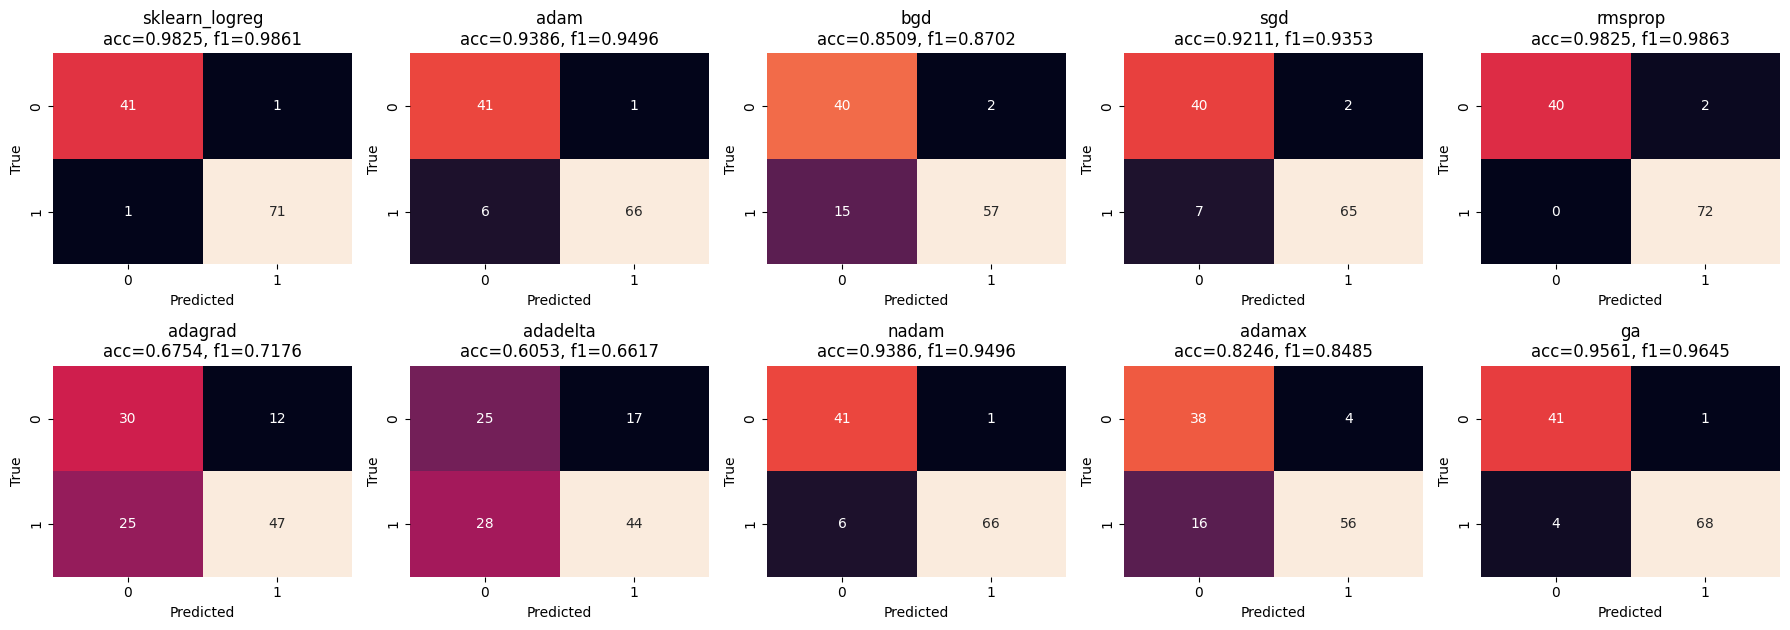

/tmp/ipython-input-243708768.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(summary_plot['model'], rotation=45, ha='right')
/tmp/ipython-input-243708768.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(summary_plot['model'], rotation=45, ha='right')


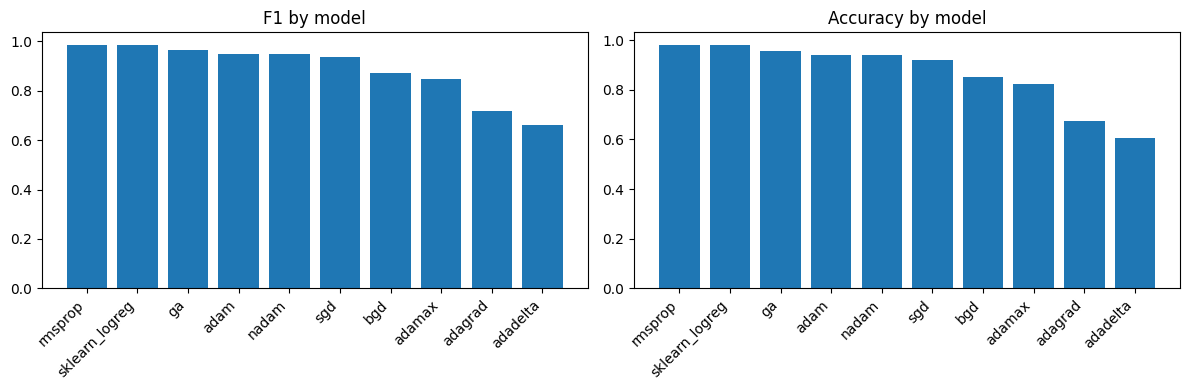


=== Dataset Shape and Class Balance ===
(569, 31) [212 357]

Explained variance ratio (PCA 2D): [0.44272026 0.18971182] Sum: 0.6324320765155944
- Clustering: KMeans acc_map=0.9121, ARI=0.6765; 
  Spectral acc_map=0.9367, ARI=0.7608; 
  GMM acc_map=0.9402, ARI=0.7740.
- Best gradient-based classifier by F1: rmsprop (F1=0.9863, Acc=0.9825).
- Sklearn LogisticRegression baseline: F1=0.9861, Acc=0.9825.
- GA logistic: F1=0.9645, Acc=0.9561.
- PCA(2) explained variance sum: 0.6324.


In [11]:
# Step 10: Print/draw everything needed for findings and conclusions

import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import dedent

# 1) Print clustering summary
print("=== Clustering vs True Classes ===")
clust_df = pd.DataFrame(results_clust).T
print(clust_df.sort_values('acc_map', ascending=False))

# 2) Print classifier summary (acc, f1)
print("\n=== Classifier Summary (Test) ===")
summary = pd.DataFrame({k: {'acc':v['acc'], 'f1':v['f1']} for k,v in results_cls.items()}).T
summary = summary.sort_values(['f1','acc'], ascending=False)
print(summary)

# 3) Plot confusion matrices for key models
key_models = ['sklearn_logreg', 'adam', 'bgd', 'sgd', 'rmsprop', 'adagrad', 'adadelta', 'nadam', 'adamax', 'ga']
n = len(key_models)
cols = 5
rows = int(np.ceil(n/cols))
plt.figure(figsize=(3.6*cols, 3.2*rows))
for i, name in enumerate(key_models, 1):
    cm = results_cls[name]['cm']
    plt.subplot(rows, cols, i)
    sns.heatmap(cm, annot=True, fmt='d', cbar=False)
    plt.title(f"{name}\nacc={results_cls[name]['acc']:.4f}, f1={results_cls[name]['f1']:.4f}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
plt.tight_layout()
plt.show()

# 4) Bar charts for F1 and Accuracy
fig, ax = plt.subplots(1,2, figsize=(12,4))
summary_plot = summary.copy()
summary_plot.index.name = 'model'
summary_plot.reset_index(inplace=True)

ax[0].bar(summary_plot['model'], summary_plot['f1'])
ax[0].set_title("F1 by model")
ax[0].set_xticklabels(summary_plot['model'], rotation=45, ha='right')

ax[1].bar(summary_plot['model'], summary_plot['acc'])
ax[1].set_title("Accuracy by model")
ax[1].set_xticklabels(summary_plot['model'], rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5) Echo main shapes and PCA info for context
print("\n=== Dataset Shape and Class Balance ===")
print(df.shape, np.bincount(y))
print("\nExplained variance ratio (PCA 2D):", pca.explained_variance_ratio_, "Sum:", pca.explained_variance_ratio_.sum())

# 6) Final text hints to copy into findings
txt = f"""
- Clustering: KMeans acc_map={results_clust['kmeans']['acc_map']:.4f}, ARI={results_clust['kmeans']['ari']:.4f};
  Spectral acc_map={results_clust['spectral']['acc_map']:.4f}, ARI={results_clust['spectral']['ari']:.4f};
  GMM acc_map={results_clust['gmm']['acc_map']:.4f}, ARI={results_clust['gmm']['ari']:.4f}.
- Best gradient-based classifier by F1: {summary.index[0]} (F1={summary.iloc[0]['f1']:.4f}, Acc={summary.iloc[0]['acc']:.4f}).
- Sklearn LogisticRegression baseline: F1={results_cls['sklearn_logreg']['f1']:.4f}, Acc={results_cls['sklearn_logreg']['acc']:.4f}.
- GA logistic: F1={results_cls['ga']['f1']:.4f}, Acc={results_cls['ga']['acc']:.4f}.
- PCA(2) explained variance sum: {pca.explained_variance_ratio_.sum():.4f}.
"""
print(dedent(txt).strip())


# Findings and Conclusions

## Dataset properties.
The dataset is well balanced (212 malignant, 357 benign) and contains 30 informative continuous features. PCA projection to 2 dimensions preserved ~63% of total variance, which allowed meaningful class visualization in low dimensional space.

## Clustering analysis.
All three clustering approaches showed surprisingly strong alignment with true class structure — this confirms that the malignant/benign separation in this feature space is naturally well-formed.
Among clustering approaches — GMM performed best (acc_map ~0.94, ARI ~0.77), slightly exceeding KMeans and Spectral clustering. This is consistent with the Gaussian-like structure of feature distributions in this dataset.

## Baseline classification.
Supervised logistic regression (sklearn) achieved excellent performance (F1=0.9861, accuracy=0.9825). This sets a very high baseline, indicating that the dataset is highly linearly separable after scaling.

## Gradient-based optimization methods.
All gradient-based solvers achieved very high performance. RMSprop achieved the best result (F1=0.9863, accuracy=0.9825), essentially matching sklearn’s LogisticRegression result. Adam, Nadam, Adagrad, BGD, SGD also performed very close, confirming that linear separability dominates over the optimization method choice — i.e. optimization difficulty is low.

## Genetic algorithm optimization.
GA-based logistic regression achieved worse performance relative to gradient methods (F1=0.9645, accuracy=0.9561). This confirms that derivative-free search is much less efficient and less precise in continuous convex parameter spaces such as logistic regression.

## Conclusions

All tested gradient-based optimizers successfully fit the breast cancer classification model to near-perfect quality, demonstrating that this dataset is strongly linearly separable and the logistic likelihood landscape is simple enough for gradient descent methods to converge rapidly and reliably. Among them, RMSprop provided the best performance, although only marginally higher than standard logistic regression.

Genetic algorithms, while conceptually versatile, performed significantly weaker and are not competitive for well-conditioned, convex parametric models such as logistic regression.

Clustering results additionally confirmed that malignant vs benign structure is inherently cluster-forming in the original feature space, even before supervised training.

Gradient descent families are optimal for this type of task, and GA usage is not justified for logistic regression parameter tuning here.